In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split


In [16]:
df=pd.read_csv("creditwise_loan_dataset.csv")
df.head()
df.shape
df.info()
# df.describe()
# df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   object 
 1   Applicant_Income    1000 non-null   int64  
 2   Coapplicant_Income  1000 non-null   int64  
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   int64  
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   int64  
 7   Credit_Score        1000 non-null   int64  
 8   Existing_Loans      1000 non-null   int64  
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   int64  
 11  Collateral_Value    1000 non-null   int64  
 12  Loan_Amount         1000 non-null   int64  
 13  Loan_Term           1000 non-null   int64  
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

Handling missing values

In [30]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["number"]).columns

# numerical_cols=df.select_dtypes(include=["float64"]).columns
# numeric_cols=df.select_dtypes(include=["int64"]).columns
# numeric_cols.size+numerical_cols.size+categorical_cols.size

categorical_cols.size+numerical_cols.size

20

In [33]:
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(strategy='mean')
df[numerical_cols]=imp_mean.fit_transform(df[numerical_cols])

imp_freq=SimpleImputer(strategy='most_frequent')
df[categorical_cols]=imp_freq.fit_transform(df[categorical_cols])
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA - exploratory data analysis

Text(0.5, 1.0, 'Is Loan approved or not?')

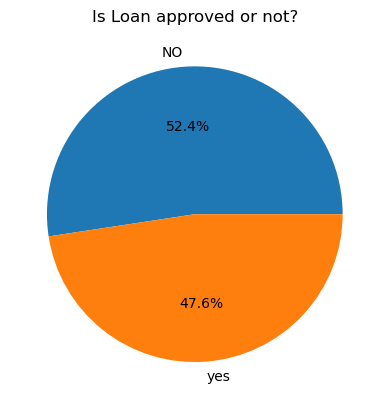

In [38]:

classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["NO","yes"],autopct="%1.1f%%")
plt.title("Is Loan approved or not?")

[Text(0, 0, '605'), Text(0, 0, '395')]

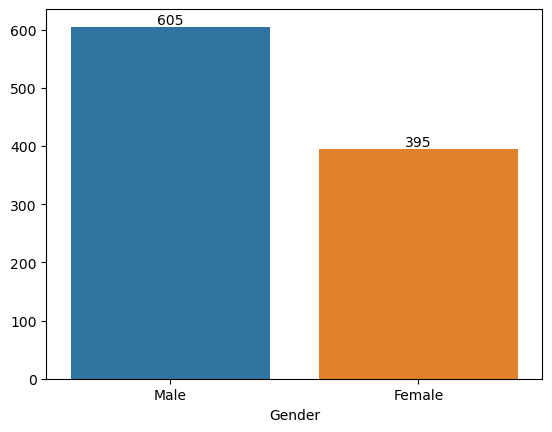

In [52]:
gen_count=df["Gender"].value_counts()
# gen_coun
ax=sns.barplot(x=gen_count.index,y=gen_count.values)
ax.bar_label(ax.containers[0])

[Text(0, 0, '516'), Text(0, 0, '269'), Text(0, 0, '215')]

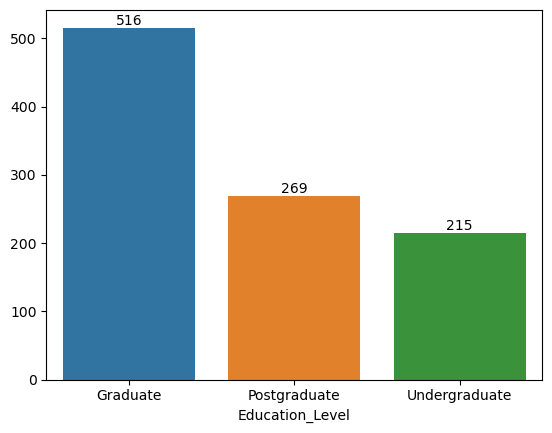

In [53]:
edu_cnt=df["Education_Level"].value_counts()
ax=sns.barplot(x=edu_cnt.index,y=edu_cnt.values)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

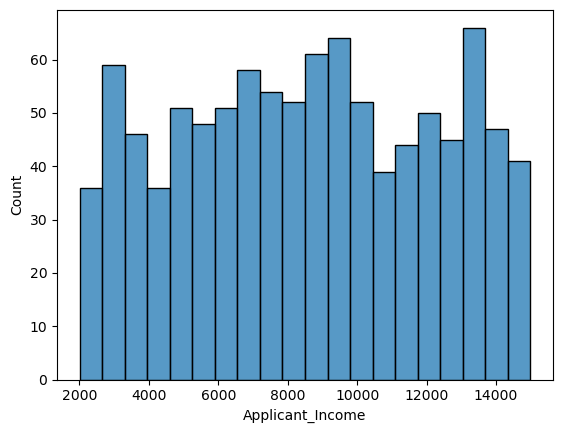

In [55]:
# analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

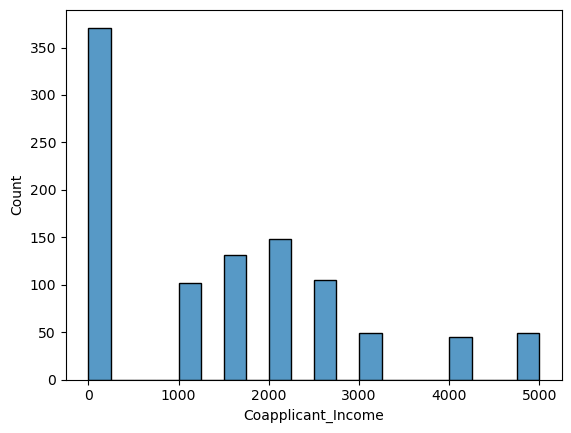

In [56]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

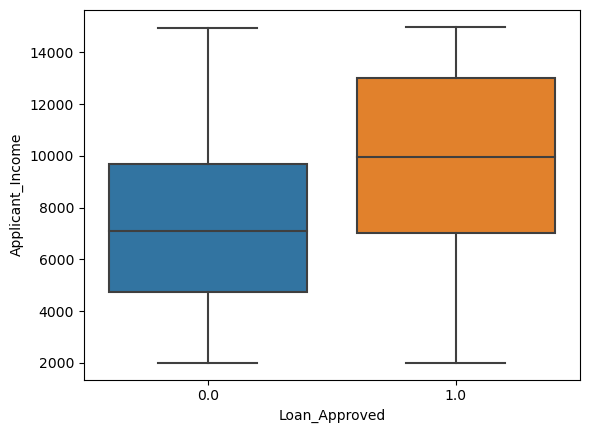

In [60]:
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

In [61]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,APP-1001,9270.0,0.0,Salaried,31.0,Single,1.0,667.0,0.0,0.16,6392.0,163650.0,43741.0,180.0,Home,Semi-Urban,Postgraduate,Male,Private,1.0
1,APP-1002,2860.0,0.0,Salaried,61.0,Married,0.0,740.0,0.0,0.48,26905.0,116034.0,11408.0,36.0,Personal,Rural,Graduate,Male,Private,0.0
2,APP-1003,7390.0,0.0,Salaried,32.0,Married,0.0,591.0,4.0,0.48,74508.0,27883.0,52903.0,360.0,Personal,Semi-Urban,Postgraduate,Male,Govt,0.0
3,APP-1004,7191.0,1500.0,Self-Employed,35.0,Single,1.0,591.0,0.0,0.50,51385.0,39782.0,117042.0,60.0,Home,Semi-Urban,Graduate,Male,Govt,0.0
4,APP-1005,13964.0,1500.0,Salaried,51.0,Married,0.0,825.0,1.0,0.54,31653.0,66387.0,142290.0,60.0,Home,Rural,Undergraduate,Male,Private,1.0


<Axes: xlabel='Loan_Approved', ylabel='Savings'>

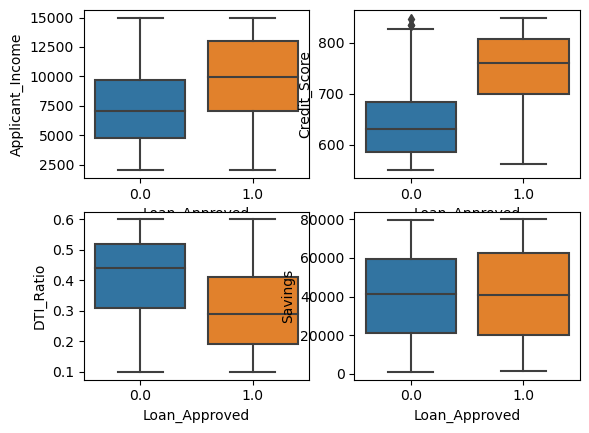

In [63]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0, 1], data=df, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1, 0], data=df, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data=df, x="Loan_Approved",y="Savings")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

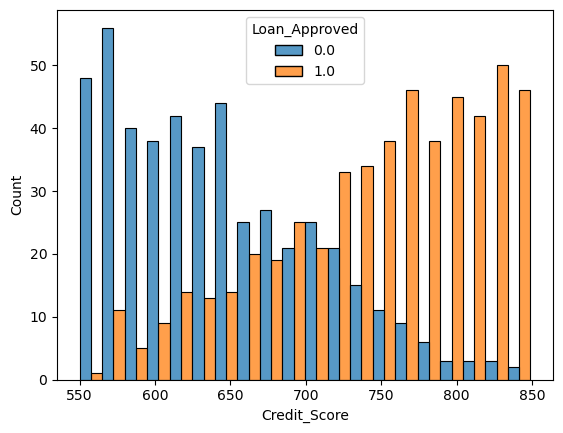

In [64]:
# Credit Score with Loan Approved

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)


<Axes: xlabel='Applicant_Income', ylabel='Count'>

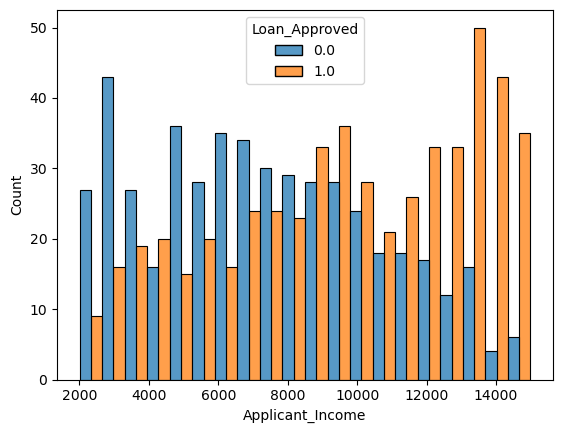

In [65]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [66]:
# Remove Applicant Id
df = df.drop("Applicant_ID", axis=1)

In [67]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,9270.0,0.0,Salaried,31.0,Single,1.0,667.0,0.0,0.16,6392.0,163650.0,43741.0,180.0,Home,Semi-Urban,Postgraduate,Male,Private,1.0
1,2860.0,0.0,Salaried,61.0,Married,0.0,740.0,0.0,0.48,26905.0,116034.0,11408.0,36.0,Personal,Rural,Graduate,Male,Private,0.0
2,7390.0,0.0,Salaried,32.0,Married,0.0,591.0,4.0,0.48,74508.0,27883.0,52903.0,360.0,Personal,Semi-Urban,Postgraduate,Male,Govt,0.0
3,7191.0,1500.0,Self-Employed,35.0,Single,1.0,591.0,0.0,0.50,51385.0,39782.0,117042.0,60.0,Home,Semi-Urban,Graduate,Male,Govt,0.0
4,13964.0,1500.0,Salaried,51.0,Married,0.0,825.0,1.0,0.54,31653.0,66387.0,142290.0,60.0,Home,Rural,Undergraduate,Male,Private,1.0


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [69]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,9270.0,0.0,Salaried,31.0,Single,1.0,667.0,0.0,0.16,6392.0,163650.0,43741.0,180.0,Home,Semi-Urban,Postgraduate,Male,Private,1.0
1,2860.0,0.0,Salaried,61.0,Married,0.0,740.0,0.0,0.48,26905.0,116034.0,11408.0,36.0,Personal,Rural,Graduate,Male,Private,0.0
2,7390.0,0.0,Salaried,32.0,Married,0.0,591.0,4.0,0.48,74508.0,27883.0,52903.0,360.0,Personal,Semi-Urban,Postgraduate,Male,Govt,0.0
3,7191.0,1500.0,Self-Employed,35.0,Single,1.0,591.0,0.0,0.50,51385.0,39782.0,117042.0,60.0,Home,Semi-Urban,Graduate,Male,Govt,0.0
4,13964.0,1500.0,Salaried,51.0,Married,0.0,825.0,1.0,0.54,31653.0,66387.0,142290.0,60.0,Home,Rural,Undergraduate,Male,Private,1.0


In [71]:
from sklearn.preprocessing import LabelEncoder
leb=LabelEncoder()
df["Education_Level"]=leb.fit_transform(df["Education_Level"])
df["Loan_Approved"]=leb.fit_transform(df["Loan_Approved"])
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,9270.0,0.0,Salaried,31.0,Single,1.0,667.0,0.0,0.16,6392.0,163650.0,43741.0,180.0,Home,Semi-Urban,1,Male,Private,1
1,2860.0,0.0,Salaried,61.0,Married,0.0,740.0,0.0,0.48,26905.0,116034.0,11408.0,36.0,Personal,Rural,0,Male,Private,0
2,7390.0,0.0,Salaried,32.0,Married,0.0,591.0,4.0,0.48,74508.0,27883.0,52903.0,360.0,Personal,Semi-Urban,1,Male,Govt,0
3,7191.0,1500.0,Self-Employed,35.0,Single,1.0,591.0,0.0,0.50,51385.0,39782.0,117042.0,60.0,Home,Semi-Urban,0,Male,Govt,0
4,13964.0,1500.0,Salaried,51.0,Married,0.0,825.0,1.0,0.54,31653.0,66387.0,142290.0,60.0,Home,Rural,2,Male,Private,1


In [72]:
categorical_cols=df.select_dtypes(include=["object"]).columns
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Gender', 'Employer_Category'],
      dtype='object')

In [74]:
ols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Correlation Heatmap

<Axes: >

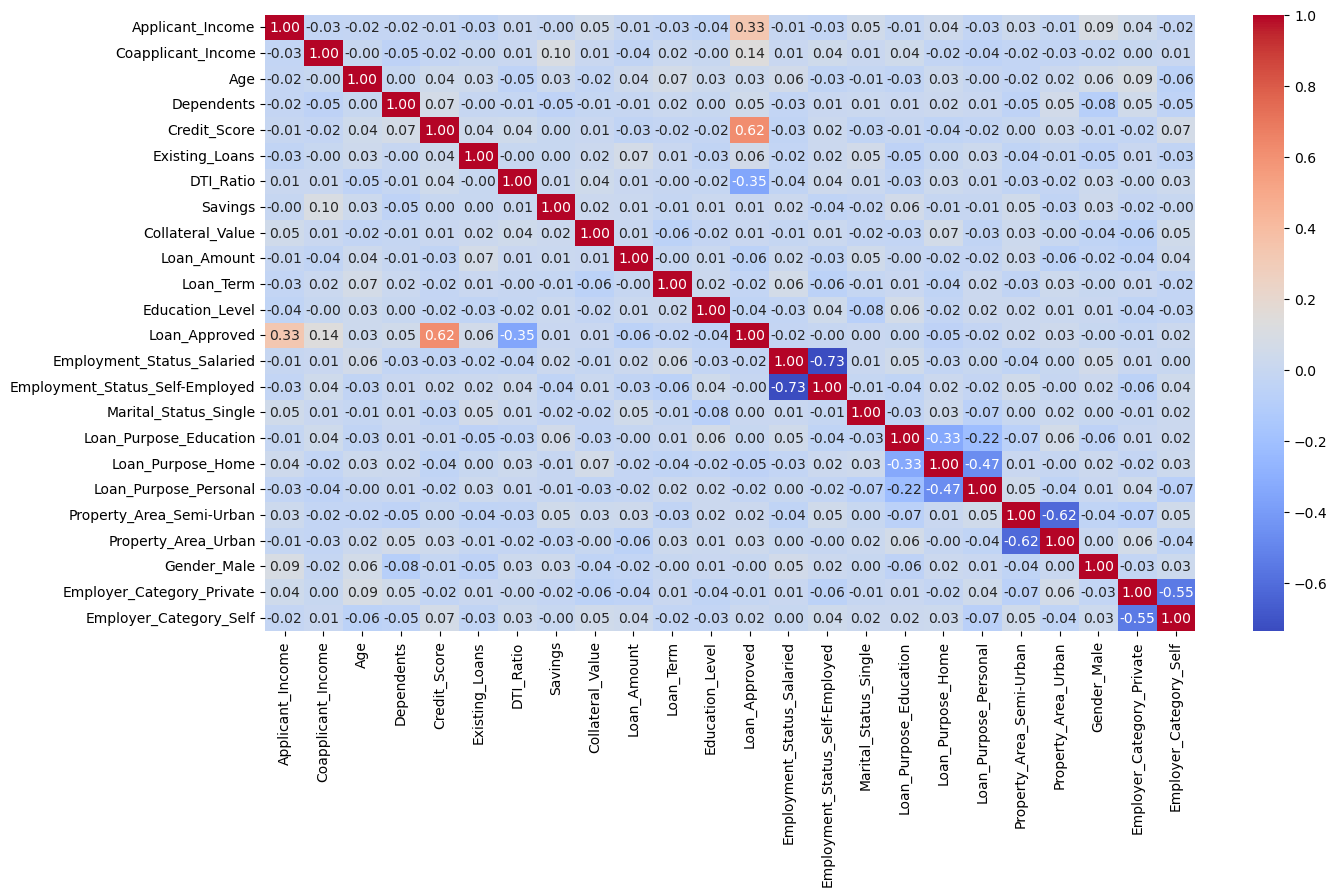

In [85]:
numeric_cols=df.select_dtypes(include="number")
corr_metrix=numeric_cols.corr()
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)



In [86]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.615635
Applicant_Income                   0.331133
Coapplicant_Income                 0.139427
Existing_Loans                     0.055609
Dependents                         0.045707
Property_Area_Urban                0.033441
Age                                0.029637
Employer_Category_Self             0.024359
Property_Area_Semi-Urban           0.020838
Collateral_Value                   0.008215
Savings                            0.007276
Marital_Status_Single              0.004514
Loan_Purpose_Education             0.002113
Gender_Male                       -0.000082
Employment_Status_Self-Employed   -0.003061
Employer_Category_Private         -0.009249
Employment_Status_Salaried        -0.016889
Loan_Purpose_Personal             -0.021993
Loan_Term                         -0.024648
Education_Level                   -0.040724
Loan_Purpose_Home                 -0.052746
Loan_Amount                     

In [87]:
# Train-Test-Split + Feature Scaling

In [99]:
from sklearn.model_selection import train_test_split

X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

y.head()


0    1
1    0
2    0
3    0
4    1
Name: Loan_Approved, dtype: int64

In [101]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_test.head()


,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Employment_Status_Self-Employed,Marital_Status_Single,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semi-Urban,Property_Area_Urban,Gender_Male,Employer_Category_Private,Employer_Category_Self
521,2512.0,3000.0,60.0,1.0,819.0,1.0,0.32,28676.0,147119.0,66063.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
737,11347.0,0.0,58.0,2.0,578.0,0.0,0.41,53587.0,44512.0,77474.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
740,9419.0,2500.0,28.0,3.0,830.0,1.0,0.46,22101.0,113393.0,111536.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
660,2728.0,1500.0,56.0,1.0,715.0,1.0,0.42,35579.0,42899.0,139473.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
411,5327.0,0.0,57.0,3.0,742.0,3.0,0.49,41934.0,171860.0,53021.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [104]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.transform(X_test)
X_test_scaled


array([[-1.66357499,  1.11535903,  1.42199278, ..., -1.23759669,
         0.87521678, -0.48038446],
       [ 0.75322359, -1.03473067,  1.2624424 , ...,  0.80801767,
         0.87521678, -0.48038446],
       [ 0.22582261,  0.75701075, -1.13081333, ..., -1.23759669,
        -1.14257407, -0.48038446],
       ...,
       [ 1.73498818, -1.03473067,  1.50176797, ...,  0.80801767,
        -1.14257407, -0.48038446],
       [ 0.64927526,  0.75701075, -1.37013891, ..., -1.23759669,
        -1.14257407,  2.081666  ],
       [ 1.1520569 ,  1.83205559,  1.50176797, ..., -1.23759669,
         0.87521678, -0.48038446]])

In [107]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
logisticmodel=LogisticRegression()
logisticmodel.fit(X_train_scaled,y_train)
y_pred=logisticmodel.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.99
Recall:  0.9611650485436893
F1 score:  0.9753694581280788
Accuracy:  0.975
CM:  [[96  1]
 [ 4 99]]


In [108]:
# Knn

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
knn=KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
y_pred=knn.predict(X_test_scaled)

# Evaluation
print("knn Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

knn Model
Precision:  0.826530612244898
Recall:  0.7864077669902912
F1 score:  0.8059701492537313
Accuracy:  0.805
CM:  [[80 17]
 [22 81]]


In [109]:
# navies

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
nb=GaussianNB()
nb.fit(X_train_scaled,y_train)
y_pred=nb.predict(X_test_scaled)

# Evaluation
print("navie_bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

navie_bayes Model
Precision:  0.8857142857142857
Recall:  0.9029126213592233
F1 score:  0.8942307692307693
Accuracy:  0.89
CM:  [[85 12]
 [10 93]]


#Feature Enginneering

In [110]:
# Add or Tranform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [111]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semi-Urban,Property_Area_Urban,Gender_Male,Employer_Category_Private,Employer_Category_Self,DTI_Ratio_sq,Credit_Score_sq
29,10666.0,0.0,24.0,1.0,2.0,17651.0,10908.0,61897.0,360.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.1369,577600.0
535,12486.0,5000.0,25.0,1.0,2.0,55215.0,113533.0,96379.0,36.0,2,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0169,720801.0
695,13174.0,0.0,47.0,1.0,3.0,79712.0,170966.0,14454.0,36.0,2,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.2209,462400.0
557,11827.0,5000.0,27.0,3.0,2.0,30739.0,77764.0,13889.0,36.0,1,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0121,329476.0
836,3581.0,0.0,33.0,1.0,2.0,25204.0,142692.0,95404.0,12.0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0121,490000.0


In [112]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 score: ", f1_score(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))

Logistic Regression Model
Precision:  0.9339622641509434
Recall:  0.9611650485436893
F1 score:  0.9473684210526316
Accuracy:  0.945
CM:  [[90  7]
 [ 4 99]]
